# Plastic Detection using YOLOv8

This project focuses on detecting plastic waste using computer vision.

## Objectives
- Detect plastic objects
- Train YOLOv8 model
- Evaluate performance


## Analysis

The model performs well overall but struggles with:
- Cloth (low data)
- Container (few samples)

Main limitation:
- Small dataset (254 images)

## Improvements

- Increase dataset size
- Balance classes
- Use YOLOv8s instead of YOLOv8n

In [42]:
!pip install ultralytics
!pip install roboflow

In [43]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow


In [46]:
rf = Roboflow(api_key="NONi9nEaxC3EYilr7NvC")
project = rf.workspace("yolo-lnkrj").project("plastic-detection-pywxk")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


Number of training images: 254


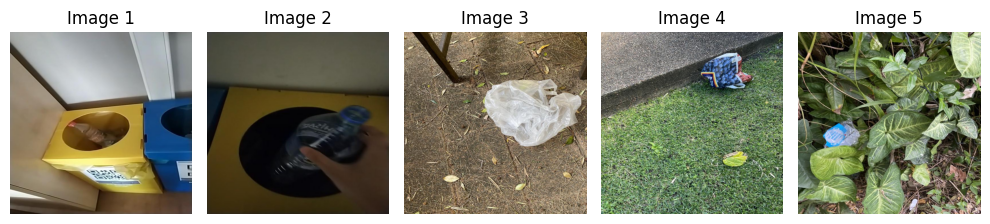

In [47]:
base_path = dataset.location
images_path = f"{base_path}/train/images"

images = os.listdir(images_path)

print(f"Number of training images: {len(images)}")

plt.figure(figsize=(10,5))

for i, img_name in enumerate(images[:5]):

    img = cv2.imread(os.path.join(images_path, img_name))

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
model = YOLO("yolov8n.pt")
model.train(data=f"{dataset.location}/data.yaml", epochs=50,augment=True)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plastic-detection-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a5252c58080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [49]:
model = YOLO("/content/runs/detect/train/weights/best.pt")
metrics=model.val()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2446.4±880.3 MB/s, size: 110.4 KB)
val: Scanning /content/plastic-detection-4/valid/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 23.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.1it/s 2.4s
                   all         68        111      0.666      0.714      0.802      0.669
                   bag         33         45      0.804      0.911      0.894      0.743
                bottle         30         39      0.886      0.897      0.916      0.653
                  bowl          3          3       0.84          1      0.995      0.962
                 cloth          7          8      0.289      0.125      0.174      0.123
             container          2        

In [52]:
print("\n=== Résultats du modèle ===")
print(f"Precision (P): {metrics.box.p.mean():.3f}")
print(f"Recall (R): {metrics.box.r.mean():.3f}")
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")


=== Résultats du modèle ===
Precision (P): 0.666
Recall (R): 0.714
mAP50: 0.802
mAP50-95: 0.669


In [39]:
#results = model.predict(source="/content/Capture d’écran 2026-04-03 175150.jpg", show=True,save=True)


image 1/1 /content/Capture d’écran 2026-04-03 175150.jpg: 416x640 1 bag, 33.2ms
Speed: 6.6ms preprocess, 33.2ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


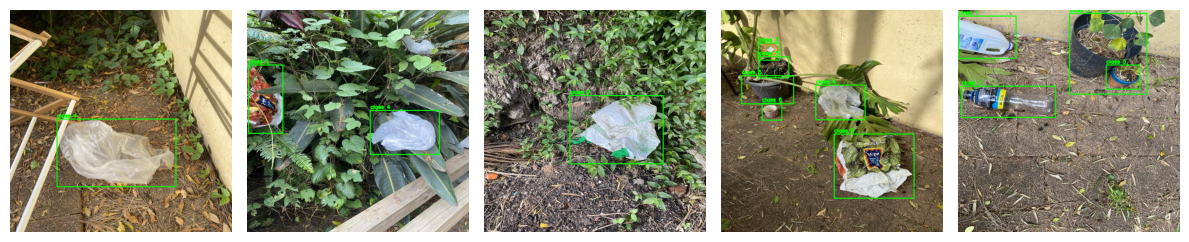

In [51]:
images_path = os.path.join(base_path, "test/images")
labels_path = os.path.join(base_path, "test/labels")

images = os.listdir(images_path)

plt.figure(figsize=(12,5))

for i, img_name in enumerate(images[:5]):

    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w, _ = img.shape

    label_name = img_name.replace(".jpg", ".txt").replace(".png", ".txt")
    label_path = os.path.join(labels_path, label_name)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(img, f"class {int(cls)}", (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()